# YOLO11n / YOLOv8n Deployment on IMX500 AI Camera (Raspberry Pi)

## Prerequisites

- Raspberry Pi 4B (8 GB RAM) with a connected Raspberry Pi AI Camera featuring a Sony IMC500 sensor
- Monitor and keyboard, or SSH, VNC, ... access to the Raspberry Pi (within the same network)
- Trained YOLO model (v8n or 11n) in `.pt` format


# 1. pt2imx (Google Colab)

If you only install Ultralytics (as described in the official documentation:
 https://docs.ultralytics.com/integrations/sony-imx500#sony-model-compression-toolkit-mct), Then you can spend hours dealing with dependency conflicts, or you might get lucky and everything works out.

https://www.reddit.com/r/raspberry_pi/comments/1r2j7le/illegal_instruction_error_with_yolov11_and_rpi4/ THANKS!!!

In [ ]:
!pip install ultralytics
!pip install torch==2.3.1 torchvision==0.18.1 protobuf==7.35.0

Load and export your own YOLO model. This process takes some time, so it is recommended to reduce the Train, Val (and optionally Test) datasets and use them as calibration data.

I have had good results with around 10 images per dataset, although the log recommends using more than 300 images.

### Example

In [ ]:
import os
import random
import shutil

path = "/content/dataset/data"  # Adjust Path

splits = ["train", "val", "test"]

keep_images = 10

for split in splits:
    split_path = os.path.join(path, split)

    if not os.path.exists(split_path):
        print(f"Skip: {split}")
        continue

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif"))
        ]

        random.shuffle(images)

        remove_images = images[keep_images:]

        for img in remove_images:
            img_path = os.path.join(class_path, img)
            os.remove(img_path)

        print(f"{split}/{class_name}: kept {min(len(images), keep_images)} images")

print("Dataset reduced.")

### Load and export YOLO model.

In [ ]:
from ultralytics import YOLO

model =YOLO("yolo11n.pt")

model.export(
    format="imx",                    # AI camera Format
    data"content/dataset/data.yaml", # Adjust path and, if necessary, the data.yaml file
    device=0                         # GPU is not essential, but slightly faster
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.3.1+cu121 CPU (Intel Xeon CPU @ 2.20GHz)
WARNING ⚠️ imx export requires int8=True, setting int8=True.
WARNING ⚠️ IMX export requires nms=True, setting nms=True.
WARNING ⚠️ IMX export does not support end2end models, disabling end2end branch.
WARNING ⚠️ INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 8400, 4), (1, 8400, 80)) (5.4 MB)
IMX: collecting INT8 calibration images from 'data=coco8.yaml'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 25.1±14.3 MB/s, size: 54.0 KB)
val: Scanning /content/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 466.0Kit/s 0.0s
WARNING ⚠️ IMX: >300 images recommended for INT8 calibration, found 4 images.


/usr/local/lib/python3.12/dist-packages/mct_quantizers/keras/quantize_wrapper.py:100: SyntaxWarning: invalid escape sequence '\l'
  attributes are integers representing the input index in the function\layer's inputs.
/usr/local/lib/python3.12/dist-packages/mct_quantizers/common/metadata.py:28: SyntaxWarning: invalid escape sequence '\i'
  metadata (Dict): metadata dictionary. Should contain only string keys and string\interger\float values or
/usr/local/lib/python3.12/dist-packages/mct_quantizers/pytorch/quantize_wrapper.py:45: SyntaxWarning: invalid escape sequence '\l'
  representing the input index in the function\layer's inputs.



IMX: starting export with model_compression_toolkit 2.4.5...


Statistics Collection: 4it [00:06,  1.58s/it]
Calculating quantization parameters: 100%|██████████| 280/280 [01:07<00:00,  4.14it/s]
88it [06:39,  4.54s/it]
/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/jit_utils.py:307: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at ../torch/csrc/jit/passes/onnx/constant_fold.cpp:179.)
  _C._jit_pass_onnx_node_shape_type_inference(node, params_dict, opset_version)
/usr/local/lib/python3.12/dist-packages/torch/onnx/utils.py:702: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onnx::Slice op. Constant folding not applied. (Triggered internally at ../torch/csrc/jit/passes/onnx/constant_fold.cpp:179.)
  _C._jit_pass_onnx_graph_shape_type_inference(
/usr/local/lib/python3.12/dist-packages/torch/onnx/utils.py:1208: UserWarning: Constant folding - Only steps=1 can be constant folded for opset >= 10 onn

IMX: export success ✅ 841.0s, saved as 'yolo11n_imx_model' (14.0 MB)

Export complete (841.6s)
Results saved to /content/yolo11n_imx_model
Predict:         yolo predict task=detect model=yolo11n_imx_model imgsz=640 int8
Validate:        yolo val task=detect model=yolo11n_imx_model imgsz=640 data=/usr/src/ultralytics/ultralytics/cfg/datasets/coco.yaml int8 
Visualize:       https://netron.app


'yolo11n_imx_model'

Package the files into a ZIP archive for download, then download it from the "Files" section on the left.

In [ ]:
import shutil

shutil.make_archive('yolo11n_imx', 'zip', '/content/yolo11n_imx_model')

'/content/yolo11n_imx.zip'

After export, the structure is as follows:

yolo11n_imx_model/

├── dnnParams.xml

├── labels.txt

├── packerOut.zip

├── model_imx.onnx

├── model_imx_MemoryReport.json

└── model_imx.pbtxt

Copy the folder to the Raspberry Pi later when needed (e.g., via USB, `wget`, `scp`, etc.).

## 2. Raspberry Pi Setup (Terminal on the Pi, NOT in Colab)

Install Raspberry Pi OS.

**IMPORTANT:** Use the 64-bit version and select the Bookworm (Legacy) OS Lite version for deployment.<br>
Use the full OS version for development.

Update the system and install the firmware.
- sudo apt update && sudo apt full-upgrade -y
- sudo apt install imx500-all

(Optional: Enable VNC to get a graphical user interface for development.)


In [ ]:
sudo raspi-config

→ Interface Options → VNC Enable

Set up venv and firmware for YOLO model deployment.

In [ ]:
python3 -m venv --system-site-packages imx500-venv # --ssp to gain access to `imx-all` and other global resources.
source imx500-venv/bin/activate

In [ ]:
pip install --upgrade pip

pip install git+https://github.com/SonySemiconductorSolutions/aitrios-rpi-application-module-library.git

In [ ]:
rpicam-hello --version

- Problem: `libcamera` 0.5.x → incompatible with newer `modlib` versions (`libcamera` 0.6+ is recommended). Therefore, we need to apply a workaround.

In [ ]:
pip uninstall modlib -y
pip install modlib==1.1.0

Instead of upgrading libcamera, downgrade modlib.

Copy the model to the Raspberry Pi, e.g., using `wget`.

In [ ]:
wget <rawgitlink/11n_imx.zip>
unzip 11n_imx.zip -d 11n_imx_model

YOLO inference Script

In [ ]:
import numpy as np
from modlib.apps import Annotator
from modlib.devices import AiCamera
from modlib.models import COLOR_FORMAT, MODEL_TYPE, Model
from modlib.models.post_processors import pp_od_yolo_ultralytics

class YOLO(Model):

    def __init__(self):
        super().__init__(
            model_file="11n_imx_model/packerOut.zip",
            model_type=MODEL_TYPE.CONVERTED,
            color_format=COLOR_FORMAT.RGB,
            preserve_aspect_ratio=False,
        )

        self.labels = np.genfromtxt(
            "11n_imx_model/labels.txt",
            dtype=str,
            delimiter="\n",
        )

    def post_process(self, output_tensors):
        return pp_od_yolo_ultralytics(output_tensors)

device = AiCamera(frame_rate=16)  # Reduce to 8 if necessary
model = YOLO()
device.deploy(model)

annotator = Annotator()

with device as stream:
    for frame in stream:

        detections = frame.detections[
            frame.detections.confidence > 0.55
        ]

        labels = [
            f"{model.labels[class_id]}: {score:.2f}"
            for _, score, class_id, _ in detections
        ]

        annotator.annotate_boxes(
            frame,
            detections,
            labels=labels,
            alpha=0.3,
            corner_radius=10,
        )

        frame.display()

Let's get started.

In [ ]:
python3 run_yolo.py

python3 run_yolo.py

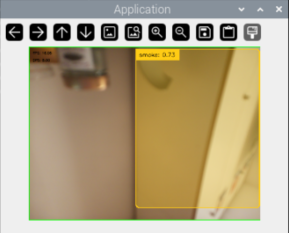

This was only a model trained on 200 samples, so the results are accordingly limited.